In [163]:
import sys
print(sys.executable)

C:\Users\User\AppData\Local\Programs\Python\Python313\python.exe


In [164]:
import os
import numpy as np
import pandas as pd
base_path = r"C:\Users\User\Downloads\hacknew\project LazaruS\data\cleaned"

demographics = pd.read_csv(os.path.join(base_path, "cleaned_patient_demographics.csv"))
telemetry = pd.read_csv(os.path.join(base_path, "cleaned_telemetry_logs.csv"))
pharmacy = pd.read_csv(os.path.join(base_path, "cleaned_prescription_audit.csv"))



In [165]:
def hex_to_int(x):
    try:
        return int(x, 16)
    except:
        return np.nan

telemetry['heart_rate_decoded'] = telemetry['heart_rate_hex'].apply(hex_to_int)

In [166]:
telemetry.head()

,packet_id,ghost_id,room_id,heart_rate_hex,spO2,heart_rate_decoded
0,0,G-528,299,0x51,97.0,81
1,1,G-343,210,0x49,96.5,73
2,2,G-305,371,0x4d,96.0,77
3,3,G-163,457,0x48,95.0,72
4,4,G-108,204,0x3e,94.0,62


In [167]:
demographics.head()

,internal_id,ghost_id,parity_group,name,age
0,0,G-100,0,Patient_0,58
1,1,G-100,1,Patient_1,50
2,2,G-101,0,Patient_2,37
3,3,G-101,1,Patient_3,52
4,4,G-102,0,Patient_4,83


In [168]:
demographics.sort_values(by=['ghost_id'], ascending=[False])

,internal_id,ghost_id,parity_group,name,age
999,999,G-599,1,Patient_999,28
998,998,G-599,0,Patient_998,68
997,997,G-598,1,Patient_997,43
996,996,G-598,0,Patient_996,84
995,995,G-597,1,Patient_995,75
...,...,...,...,...,...
5,5,G-102,1,Patient_5,55
2,2,G-101,0,Patient_2,37
3,3,G-101,1,Patient_3,52
1,1,G-100,1,Patient_1,50


In [169]:
demographics.head(345)

,internal_id,ghost_id,parity_group,name,age
0,0,G-100,0,Patient_0,58
1,1,G-100,1,Patient_1,50
2,2,G-101,0,Patient_2,37
3,3,G-101,1,Patient_3,52
4,4,G-102,0,Patient_4,83
...,...,...,...,...,...
340,340,G-270,0,Patient_340,61
341,341,G-270,1,Patient_341,55
342,342,G-271,0,Patient_342,54
343,343,G-271,1,Patient_343,19


In [170]:
from sklearn.preprocessing import StandardScaler

features = telemetry[['heart_rate_decoded', 'spO2']].copy()


features = features.fillna(features.mean())


scaler = StandardScaler()
X = scaler.fit_transform(features)

In [171]:
telemetry.head()

,packet_id,ghost_id,room_id,heart_rate_hex,spO2,heart_rate_decoded
0,0,G-528,299,0x51,97.0,81
1,1,G-343,210,0x49,96.5,73
2,2,G-305,371,0x4d,96.0,77
3,3,G-163,457,0x48,95.0,72
4,4,G-108,204,0x3e,94.0,62


In [172]:
telemetry["ghost_id"].value_counts()

ghost_id
G-342    33
G-331    32
G-287    31
G-449    31
G-328    31
         ..
G-437    11
G-109    10
G-118    10
G-320     9
G-589     8
Name: count, Length: 500, dtype: int64

In [173]:
data=telemetry

In [174]:
df1=data

In [175]:
df1.head()

,packet_id,ghost_id,room_id,heart_rate_hex,spO2,heart_rate_decoded
0,0,G-528,299,0x51,97.0,81
1,1,G-343,210,0x49,96.5,73
2,2,G-305,371,0x4d,96.0,77
3,3,G-163,457,0x48,95.0,72
4,4,G-108,204,0x3e,94.0,62


In [176]:


data = data.merge(
    demographics[['ghost_id', 'parity_group', 'age']],
    on='ghost_id',
    how='left'
)

In [177]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import pickle


gmm1 = None
scaler = None

def adjust_heart_rate(row):
    age = row['age']
    hr = row['heart_rate_decoded']
    return hr + (50 - age) * 0.3

def adjust_spo2(row):
    age = row['age']
    spo2 = row['spO2']
    return spo2 + (50 - age) * 0.02


data['hr_adjusted'] = data.apply(adjust_heart_rate, axis=1)
data['spo2_adjusted'] = data.apply(adjust_spo2, axis=1)

def differentiate_duplicates(group):
    group = group.copy().reset_index(drop=True)
    if len(group) > 1:
        for idx in range(len(group)):
            unique_offset = (idx + 1) * 0.85
            group.loc[idx, 'hr_adjusted'] += unique_offset
            group.loc[idx, 'spo2_adjusted'] -= unique_offset * 0.05
    return group

data = data.groupby(['ghost_id', 'age'], group_keys=False).apply(differentiate_duplicates)

def resolve_with_gmm(df):
    global gmm1, scaler 
    df = df.copy()

    if len(df) < 3:
        df['cluster'] = range(len(df))
        return df

    features = df[['hr_adjusted', 'spo2_adjusted', 'age', 'parity_group']].copy()
    features = features.fillna(features.mean())
    features['age_hr_interaction'] = features['hr_adjusted'] * (features['age'] / 50)
    features['unique_signal'] = np.arange(len(df)) * 0.01

    scaler = StandardScaler()
    X = scaler.fit_transform(features)

    lowest_bic = np.inf
    best_k = 1
    for k in range(1, min(5, len(df))):
        test_gmm = GaussianMixture(n_components=k, random_state=42)
        test_gmm.fit(X)
        bic = test_gmm.bic(X)
        if bic < lowest_bic:
            lowest_bic = bic
            best_k = k

    gmm1 = GaussianMixture(n_components=best_k, random_state=42)
    df['cluster'] = gmm1.fit_predict(X)

    if len(df['cluster'].unique()) == 1:
        df['cluster'] = pd.qcut(
            df['hr_adjusted'],
            q=2,
            labels=False,
            duplicates='drop'
        )

    return df

data = data.groupby('ghost_id', group_keys=False).apply(resolve_with_gmm)

data['patient_id'] = (
    data['ghost_id'].astype(str) + "_" +
    data['parity_group'].astype(str) + "_" +
    data['cluster'].astype(str)
)




C:\TEMP\ipykernel_1262276\1255459934.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby(['ghost_id', 'age'], group_keys=False).apply(differentiate_duplicates)
C:\TEMP\ipykernel_1262276\1255459934.py:75: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby('ghost_id', group_keys=False).apply(resolve_with_gmm)


In [178]:

duplicate_columns = ['hr_adjusted', 'spo2_adjusted']


data_unique = data.drop_duplicates(subset=duplicate_columns, keep='first').reset_index(drop=True)



In [179]:
data.head()

,packet_id,ghost_id,room_id,heart_rate_hex,spO2,heart_rate_decoded,parity_group,age,hr_adjusted,spo2_adjusted,cluster,patient_id
0,383,G-100,182,0x67,95.0,103,1,50,103.85,94.9575,0,G-100_1_0
1,1147,G-100,470,0x5b,93.0,91,1,50,92.70,92.9150,0,G-100_1_0
2,1320,G-100,488,0x5d,99.0,93,1,50,95.55,98.8725,0,G-100_1_0
3,1641,G-100,315,0x3c,93.0,60,1,50,63.40,92.8300,0,G-100_1_0
4,3101,G-100,261,0x60,100.0,96,1,50,100.25,99.7875,0,G-100_1_0


In [180]:
data.duplicated()

0     False
1     False
2     False
3     False
4     False
      ...  
18    False
19    False
20    False
21    False
22    False
Length: 20000, dtype: bool

In [181]:

pharmacy = pharmacy.drop_duplicates(subset=['ghost_id'], keep='first')

df = data.merge(
    pharmacy,
    on='ghost_id',
    how='left'
)

In [182]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
19995    False
19996    False
19997    False
19998    False
19999    False
Length: 20000, dtype: bool

In [183]:
def decrypt(text, shift):
    result = ""
    for char in str(text):
        if char.isalpha():
            result += chr((ord(char) - shift - 65) % 26 + 65)
        else:
            result += char
    return result

df['decrypted_med'] = df.apply(
    lambda row: decrypt(row['scrambled_med'], int(row['age']) % 26),
    axis=1
)

In [184]:
dfnew=df

In [185]:
dfnew.head()

,packet_id,ghost_id,room_id,heart_rate_hex,spO2,heart_rate_decoded,parity_group,age,hr_adjusted,spo2_adjusted,cluster,patient_id,rx_id,scrambled_med,decrypted_med
0,383,G-100,182,0x67,95.0,103,1,50,103.85,94.9575,0,G-100_1_0,4311,LQVXOLQ,NSXZQNS
1,1147,G-100,470,0x5b,93.0,91,1,50,92.70,92.9150,0,G-100_1_0,4311,LQVXOLQ,NSXZQNS
2,1320,G-100,488,0x5d,99.0,93,1,50,95.55,98.8725,0,G-100_1_0,4311,LQVXOLQ,NSXZQNS
3,1641,G-100,315,0x3c,93.0,60,1,50,63.40,92.8300,0,G-100_1_0,4311,LQVXOLQ,NSXZQNS
4,3101,G-100,261,0x60,100.0,96,1,50,100.25,99.7875,0,G-100_1_0,4311,LQVXOLQ,NSXZQNS


In [186]:
dfnew['spO2'] = dfnew['spO2'].interpolate(method='linear')
dfnew['heart_rate_decoded'] = dfnew['heart_rate_decoded'].interpolate(method='linear')
dfnew = dfnew[
    (dfnew['heart_rate_decoded'] >= 40) &
    (dfnew['heart_rate_decoded'] <= 180)
]

In [187]:
dfnew.head()

,packet_id,ghost_id,room_id,heart_rate_hex,spO2,heart_rate_decoded,parity_group,age,hr_adjusted,spo2_adjusted,cluster,patient_id,rx_id,scrambled_med,decrypted_med
0,383,G-100,182,0x67,95.0,103,1,50,103.85,94.9575,0,G-100_1_0,4311,LQVXOLQ,NSXZQNS
1,1147,G-100,470,0x5b,93.0,91,1,50,92.70,92.9150,0,G-100_1_0,4311,LQVXOLQ,NSXZQNS
2,1320,G-100,488,0x5d,99.0,93,1,50,95.55,98.8725,0,G-100_1_0,4311,LQVXOLQ,NSXZQNS
3,1641,G-100,315,0x3c,93.0,60,1,50,63.40,92.8300,0,G-100_1_0,4311,LQVXOLQ,NSXZQNS
4,3101,G-100,261,0x60,100.0,96,1,50,100.25,99.7875,0,G-100_1_0,4311,LQVXOLQ,NSXZQNS


In [188]:
dfnew.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
19995    False
19996    False
19997    False
19998    False
19999    False
Length: 20000, dtype: bool

In [189]:
df1=dfnew

In [190]:
df1.count()

packet_id             20000
ghost_id              20000
room_id               20000
heart_rate_hex        20000
spO2                  20000
heart_rate_decoded    20000
parity_group          20000
age                   20000
hr_adjusted           20000
spo2_adjusted         20000
cluster               20000
patient_id            20000
rx_id                 20000
scrambled_med         20000
decrypted_med         20000
dtype: int64

In [191]:
df2=df1

In [192]:
df1.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
19995    False
19996    False
19997    False
19998    False
19999    False
Length: 20000, dtype: bool

In [193]:
print(df2.columns)

Index(['packet_id', 'ghost_id', 'room_id', 'heart_rate_hex', 'spO2',
       'heart_rate_decoded', 'parity_group', 'age', 'hr_adjusted',
       'spo2_adjusted', 'cluster', 'patient_id', 'rx_id', 'scrambled_med',
       'decrypted_med'],
      dtype='object')


In [194]:
df2.head()

,packet_id,ghost_id,room_id,heart_rate_hex,spO2,heart_rate_decoded,parity_group,age,hr_adjusted,spo2_adjusted,cluster,patient_id,rx_id,scrambled_med,decrypted_med
0,383,G-100,182,0x67,95.0,103,1,50,103.85,94.9575,0,G-100_1_0,4311,LQVXOLQ,NSXZQNS
1,1147,G-100,470,0x5b,93.0,91,1,50,92.70,92.9150,0,G-100_1_0,4311,LQVXOLQ,NSXZQNS
2,1320,G-100,488,0x5d,99.0,93,1,50,95.55,98.8725,0,G-100_1_0,4311,LQVXOLQ,NSXZQNS
3,1641,G-100,315,0x3c,93.0,60,1,50,63.40,92.8300,0,G-100_1_0,4311,LQVXOLQ,NSXZQNS
4,3101,G-100,261,0x60,100.0,96,1,50,100.25,99.7875,0,G-100_1_0,4311,LQVXOLQ,NSXZQNS


In [195]:

def validate_signal(df1):
    df1 = df1.copy()

   
    df1['hr_diff'] = df1['heart_rate_decoded'].diff().abs()

    
    df1['spo2_diff'] = df1['spO2'].diff().abs()

    df1['valid'] = (
        (df1['hr_diff'] < 40) &   
        (df1['spo2_diff'] < 5)    
    )

    return df1

df1 = df1.groupby('patient_id', group_keys=False).apply(validate_signal)


df1 = df1[df1['valid'] == True]

C:\TEMP\ipykernel_1262276\118857342.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df1 = df1.groupby('patient_id', group_keys=False).apply(validate_signal)


In [196]:
df1.head()

,packet_id,ghost_id,room_id,heart_rate_hex,spO2,heart_rate_decoded,parity_group,age,hr_adjusted,spo2_adjusted,cluster,patient_id,rx_id,scrambled_med,decrypted_med,hr_diff,spo2_diff,valid
1,1147,G-100,470,0x5b,93.0,91,1,50,92.70,92.9150,0,G-100_1_0,4311,LQVXOLQ,NSXZQNS,12.0,2.0,True
5,3694,G-100,452,0x6c,98.5,108,1,50,113.10,98.2450,0,G-100_1_0,4311,LQVXOLQ,NSXZQNS,12.0,1.5,True
6,3842,G-100,215,0x63,95.0,99,1,50,104.95,94.7025,0,G-100_1_0,4311,LQVXOLQ,NSXZQNS,9.0,3.5,True
7,4035,G-100,261,0x56,95.0,86,1,50,92.80,94.6600,0,G-100_1_0,4311,LQVXOLQ,NSXZQNS,13.0,0.0,True
8,4293,G-100,225,0x40,92.0,64,1,50,71.65,91.6175,0,G-100_1_0,4311,LQVXOLQ,NSXZQNS,22.0,3.0,True


In [197]:
print(df1.columns)

Index(['packet_id', 'ghost_id', 'room_id', 'heart_rate_hex', 'spO2',
       'heart_rate_decoded', 'parity_group', 'age', 'hr_adjusted',
       'spo2_adjusted', 'cluster', 'patient_id', 'rx_id', 'scrambled_med',
       'decrypted_med', 'hr_diff', 'spo2_diff', 'valid'],
      dtype='object')


In [198]:

from scipy.interpolate import UnivariateSpline

def smooth_signals(df1):
    df1 = df1.copy()

    if len(df1) < 4:
        return df1

    x = np.arange(len(df1))

   
    spline_hr = UnivariateSpline(x, df1['heart_rate_decoded'], s=5)
    df1['hr_smooth'] = spline_hr(x)

  
    spline_spo2 = UnivariateSpline(x, df1['spO2'], s=2)
    df1['spo2_smooth'] = spline_spo2(x)

    return df1

df1 = df1.groupby('patient_id', group_keys=False).apply(smooth_signals)

C:\TEMP\ipykernel_1262276\1074858928.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df1 = df1.groupby('patient_id', group_keys=False).apply(smooth_signals)


In [199]:
df1['heart_rate_final'] = df1['hr_smooth'].fillna(df1['heart_rate_decoded'])
df1['spo2_final'] = df1['spo2_smooth'].fillna(df1['spO2'])

In [200]:
df1.head()

,packet_id,ghost_id,room_id,heart_rate_hex,spO2,heart_rate_decoded,parity_group,age,hr_adjusted,spo2_adjusted,...,rx_id,scrambled_med,decrypted_med,hr_diff,spo2_diff,valid,hr_smooth,spo2_smooth,heart_rate_final,spo2_final
1,1147,G-100,470,0x5b,93.0,91,1,50,92.70,92.9150,...,4311,LQVXOLQ,NSXZQNS,12.0,2.0,True,91.015344,93.024302,91.015344,93.024302
5,3694,G-100,452,0x6c,98.5,108,1,50,113.10,98.2450,...,4311,LQVXOLQ,NSXZQNS,12.0,1.5,True,107.905336,98.378096,107.905336,98.378096
6,3842,G-100,215,0x63,95.0,99,1,50,104.95,94.7025,...,4311,LQVXOLQ,NSXZQNS,9.0,3.5,True,99.279379,95.262943,99.279379,95.262943
7,4035,G-100,261,0x56,95.0,86,1,50,92.80,94.6600,...,4311,LQVXOLQ,NSXZQNS,13.0,0.0,True,85.457855,94.665969,85.457855,94.665969
8,4293,G-100,225,0x40,92.0,64,1,50,71.65,91.6175,...,4311,LQVXOLQ,NSXZQNS,22.0,3.0,True,64.787204,92.317442,64.787204,92.317442


In [201]:
df1.count()

packet_id             14340
ghost_id              14340
room_id               14340
heart_rate_hex        14340
spO2                  14340
heart_rate_decoded    14340
parity_group          14340
age                   14340
hr_adjusted           14340
spo2_adjusted         14340
cluster               14340
patient_id            14340
rx_id                 14340
scrambled_med         14340
decrypted_med         14340
hr_diff               14340
spo2_diff             14340
valid                 14340
hr_smooth             14334
spo2_smooth           14334
heart_rate_final      14340
spo2_final            14340
dtype: int64

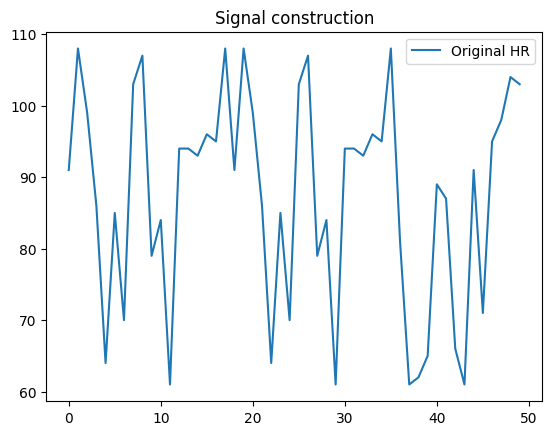

In [202]:
import matplotlib.pyplot as plt
plt.figure()

plt.plot(df1['heart_rate_decoded'].values[:50], label="Original HR")


plt.legend()
plt.title("Signal construction")
plt.show()

In [203]:

LOW_HR = 60
HIGH_HR = 100


LOW_SPO2 = 92
CRITICAL_SPO2 = 88

def classify_heart_rate(hr):
    if hr < LOW_HR:
        return "LOW"
    elif hr > HIGH_HR:
        return "HIGH"
    else:
        return "NORMAL"

def classify_spo2(spo2):
    if spo2 < CRITICAL_SPO2:
        return "CRITICAL"
    elif spo2 < LOW_SPO2:
        return "LOW"
    else:
        return "NORMAL"

In [204]:
print(df1.columns)

Index(['packet_id', 'ghost_id', 'room_id', 'heart_rate_hex', 'spO2',
       'heart_rate_decoded', 'parity_group', 'age', 'hr_adjusted',
       'spo2_adjusted', 'cluster', 'patient_id', 'rx_id', 'scrambled_med',
       'decrypted_med', 'hr_diff', 'spo2_diff', 'valid', 'hr_smooth',
       'spo2_smooth', 'heart_rate_final', 'spo2_final'],
      dtype='object')


In [205]:
df1['hr_status'] = df1['hr_adjusted'].apply(classify_heart_rate)
df1['spo2_status'] = df1['spo2_adjusted'].apply(classify_spo2)

In [206]:
def overall_status(row):
    if row['spo2_status'] == "CRITICAL":
        return "CRITICAL"
    elif row['hr_status'] == "HIGH" or row['hr_status'] == "LOW":
        return "WARNING"
    else:
        return "STABLE"

df1['overall_status'] = df1.apply(overall_status, axis=1)

In [207]:
print(df1.columns)

Index(['packet_id', 'ghost_id', 'room_id', 'heart_rate_hex', 'spO2',
       'heart_rate_decoded', 'parity_group', 'age', 'hr_adjusted',
       'spo2_adjusted', 'cluster', 'patient_id', 'rx_id', 'scrambled_med',
       'decrypted_med', 'hr_diff', 'spo2_diff', 'valid', 'hr_smooth',
       'spo2_smooth', 'heart_rate_final', 'spo2_final', 'hr_status',
       'spo2_status', 'overall_status'],
      dtype='object')


In [208]:
df1 = df1.drop(columns=['name'], errors='ignore')

df1 = df1.merge(
    demographics[['ghost_id', 'name']],
    on='ghost_id',
    how='left'
)

In [209]:
print(df1.columns)

Index(['packet_id', 'ghost_id', 'room_id', 'heart_rate_hex', 'spO2',
       'heart_rate_decoded', 'parity_group', 'age', 'hr_adjusted',
       'spo2_adjusted', 'cluster', 'patient_id', 'rx_id', 'scrambled_med',
       'decrypted_med', 'hr_diff', 'spo2_diff', 'valid', 'hr_smooth',
       'spo2_smooth', 'heart_rate_final', 'spo2_final', 'hr_status',
       'spo2_status', 'overall_status', 'name'],
      dtype='object')


In [210]:
final_df = df1[[
    'patient_id',
    'name',
    'ghost_id',
    'age',
    'heart_rate_hex',        
    'heart_rate_decoded',      
    'hr_adjusted',
    'spo2_adjusted',
    'hr_status',
    'spo2_status',
    'overall_status'
]]

In [211]:
final=final_df

In [212]:
final_df=final_df.drop_duplicates(subset=['hr_adjusted','spo2_adjusted'],keep='first').reset_index(drop=True)

In [213]:
final_df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
14172    False
14173    False
14174    False
14175    False
14176    False
Length: 14177, dtype: bool

In [214]:
final_df.to_csv("trustmeicandoit_data.csv", index=False)

In [215]:
import pickle

# 1. Save the Scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 2. Save the GMM Model (using 'gmm1' as seen in your notebook)
with open('gmm_model.pkl', 'wb') as f:
    pickle.dump(gmm1, f)

print("Files saved successfully using pickle!")

Files saved successfully using pickle!
